In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import re
sys.path.insert(0, "../include")
from gc_utils import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [2]:
pair_c = np.loadtxt('../data/pair-T-reduce-1937d2e7-0dba-4575-9c7f-82c3338b71ef.dat',skiprows=2)
pair_gc = np.loadtxt('../data/pair-T-reduce-60931023-3b28-40bd-be4f-f8cb07882a64.dat',skiprows=2)
sq_c = np.loadtxt('../data/ssfq-T-reduce-1937d2e7-0dba-4575-9c7f-82c3338b71ef.dat', skiprows=3)
sq_gc = np.loadtxt('../data/ssfq-T-reduce-60931023-3b28-40bd-be4f-f8cb07882a64.dat', skiprows=3)
#Get q-vectos
with open('../data/ssfq-T-reduce-1937d2e7-0dba-4575-9c7f-82c3338b71ef.dat', 'r') as file:
    first_line = file.readline()
    numbers_str = re.findall(r'[-+]?\d*\.\d+E[+-]\d+|[-+]?\d+\.\d+|\d+', first_line)
    q_arr = [float(num) for num in numbers_str[1:]]
q_arr = np.array(q_arr)

In [3]:
L = 200
T = 2
mu = 14.8
rho = 0.25
xdata = pair_gc[:,0]
Sqc = sq_c[:,1][q_arr > 0]
Sqgc = sq_gc[:,1][q_arr > 0]
Sqc_err = sq_c[:,2][q_arr > 0]
Sqgc_err = sq_gc[:,2][q_arr > 0]
qarr = q_arr[q_arr > 0]/(2*np.pi*0.25)

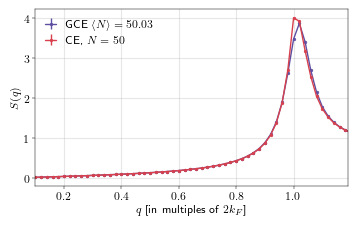

In [4]:
with plt.style.context('../include/aps.mplstyle'):
    figsize = plt.rcParams['figure.figsize']
    fig, ax = plt.subplots(constrained_layout=True, figsize=(figsize[0],figsize[1]))
    ax.errorbar(qarr,Sqgc, yerr=Sqgc_err,marker='o',label=r'GCE $\langle N\rangle = 50.03$')
    ax.errorbar(qarr,Sqc, yerr=Sqc_err,marker='o',color='#D7414E',label=r'CE, $N = 50$')
    ax.set_xlabel(r'$q$ [in multiples of $2k_F$]')
    ax.set_ylabel(r'$S(q)$')
    ax.legend(loc = 2)
    ax.set_xlim(0.1,1.19)
    #ax.set_ylim(3,4)
    ax.grid(True, alpha=0.3)
    plt.savefig('../figures/1DHeStrucFac.pdf')

In [5]:
#Fit to obtain K:
coeffs, cov = np.polyfit(np.abs(qarr[:11]), Sqgc[:11], 1, cov=True)
K_Fit    = 1/coeffs[0]
print(K_Fit)

5.227789722754689


In [6]:
osc_gc, amp_gc, phase_gc = extract_oscillation(pair_gc[:,0],pair_gc[:,1]-1, 2*np.pi*rho)
osc_c, amp_c, phase_c = extract_oscillation(pair_c[:,0],pair_c[:,1]-1, 2*np.pi*rho)

In [7]:
canonical_fit_func = lambda x, K, v, A: canonical_envelope(x,K,v,A, L,T,rho,1)
grandcanonical_fit_func = lambda x, K, v, A: grandcanonical_envelope(x,K,v,A, L,T,rho,1,0.0)
canonical_fit_funcosc = lambda x, K, v, A: canonical_osc(x,K,v,A, L,T,rho,1)
grandcanonical_fit_funcosc = lambda x, K, v, A: grandcanonical_osc(x,K,v,A, L,T,rho,1,0.0)

In [8]:
popt, pcov = curve_fit(grandcanonical_fit_funcosc, pair_gc[200:,0], amp_gc[200:], p0=[5.358995448065145, 38.197186342209264, 0.0027746639098126793], bounds=([4.0, 10,0], [10, 100,1]))
K, v_s,A = popt
gc_fitp = [K,v_s,A]
popt, pcov = curve_fit(canonical_fit_funcosc, pair_gc[100:,0], amp_gc[100:], p0=[5.358995448065145, 38.197186342209264, 0.0027746639098126793], bounds=([4.0, 10,-1], [10, 100,1]))
K, v_s,A = popt
c_fitp = [K,v_s,A]

In [28]:
plotskip = 40
with plt.style.context('../include/aps.mplstyle'):
    figsize = plt.rcParams['figure.figsize']
    fig, ax = plt.subplots(2,1,constrained_layout=True, figsize=(figsize[0],2*figsize[1]),sharex=True)
    ax[0].plot(xdata/L,pair_c[:,1]-1,'r-',label='CE')
    ax[0].plot(xdata/L,pair_gc[:,1]-1,'b-',label='GCE')
    ax[0].legend(loc=1)
    ax[0].set_ylim(-0.19,0.19)
    ax[0].set_ylabel(r'$\langle \rho(x)\rho(0)\rangle/\rho_0^2 - 1$')
    ax[1].plot(xdata/L, pair_gc[:,1]-1, 'b-', alpha=0.5, linewidth=1)
    ax[1].plot((xdata/L)[plotskip:], grandcanonical_fit_func(xdata, gc_fitp[0],gc_fitp[1],gc_fitp[2])[plotskip:], 'k--')
    ax[1].plot((xdata/L)[plotskip:], -grandcanonical_fit_func(xdata, gc_fitp[0],gc_fitp[1],gc_fitp[2])[plotskip:], 'k--',label=rf'GCE fit ($K={gc_fitp[0]:.3f}$, $v={gc_fitp[1]:.3f}$)')
    ax[1].plot((xdata/L)[plotskip:], canonical_fit_func(xdata, c_fitp[0],c_fitp[1],c_fitp[2])[plotskip:], 'g--')
    ax[1].plot((xdata/L)[plotskip:], -canonical_fit_func(xdata,c_fitp[0],c_fitp[1],c_fitp[2])[plotskip:], 'g--',label=rf'CE fit ($K={c_fitp[0]:.3f}$, $v={c_fitp[1]:.3f}$)')
    ax[1].set_xlabel(r'$x/L$')
    ax[1].set_ylabel(r'$\langle \rho(x)\rho(0)\rangle/\rho_0^2 - 1$')
    axins1 = ax[1].inset_axes([0.6, 0.1, 0.3, 0.3]) #Inset 
    axins1.plot(xdata/L, pair_gc[:,1]-1, 'b-', alpha=0.5, linewidth=1)
    axins1.plot((xdata/L)[plotskip:], grandcanonical_fit_func(xdata, gc_fitp[0],gc_fitp[1],gc_fitp[2])[plotskip:], 'k--')
    axins1.plot((xdata/L)[plotskip:], -grandcanonical_fit_func(xdata, gc_fitp[0],gc_fitp[1],gc_fitp[2])[plotskip:], 'k--')
    axins1.plot((xdata/L)[plotskip:], canonical_fit_func(xdata, c_fitp[0],c_fitp[1],c_fitp[2])[plotskip:], 'g--')
    axins1.plot((xdata/L)[plotskip:], -canonical_fit_func(xdata,c_fitp[0],c_fitp[1],c_fitp[2])[plotskip:], 'g--')
    axins1.set_xlim(0.32, 0.49)
    axins1.set_ylim(-0.01, 0.01)
    axins1.tick_params(labelsize=7)
    mark_inset(ax[1], axins1, loc1=2, loc2=4, fc="none", ec="0.5")
    ax[1].legend(loc=1)
    ax[0].grid(True, alpha=0.3)
    ax[1].grid(True, alpha=0.3)
    ax[1].set_xlim(0.0,0.49)
    ax[1].set_ylim(-0.19,0.19)
    plt.savefig('../figures/1DHePairCorrFit.pdf')